## Załadowanie bibliotek

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [12]:
# pozbycie się notacji naukowej
np.set_printoptions(suppress=True)

### Nazwy i jednostki zmiennych: 
#### Zmienna objaśniana (zależna):
*	Y - Oczekiwana długość życia w momencie urodzenia (wyrażona w latach).
#### Zmienne objaśniające (niezależne):
*	X1 - Produkt Krajowy Brutto per capita (wyrażony w tys. EUR).
*	X2 - Udział wydatków na ochronę zdrowia w PKB (wyrażone w %).
*	X3 - Odsetek populacji palącej papierosy (wyrażony w %).
*	X4 - Odsetek populacji w wieku 15-64 lata posiadającej wyższe wykształcenie (wyrażony w %). 


### Wczytanie danych

In [13]:
data = pd.read_csv('../data/dane_finalne.csv', sep=';', decimal=',')
print(data.head())

    country     Y     X1         X2  X3    X4
0  Bulgaria  75.8  14.66   7.933980  21  26.7
1   Czechia  79.9  29.33   8.421847  37  23.5
2   Denmark  81.8  62.91   9.594595  23  35.5
3   Germany  81.1  50.66  11.673909  14  28.7
4   Estonia  79.1  28.08   7.438437  24  36.0


### wizualizacja danych matrix scatter plot, korelacje 

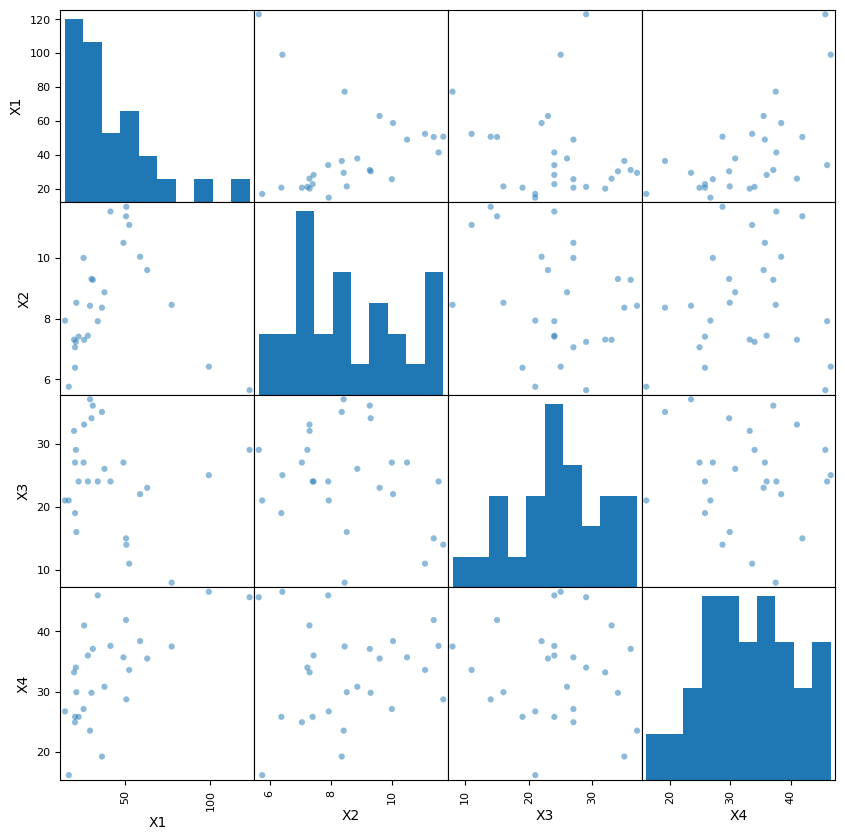

In [14]:
pd.plotting.scatter_matrix(data.drop(columns=['country', 'Y']), figsize=(10, 10), s=80)
plt.show()

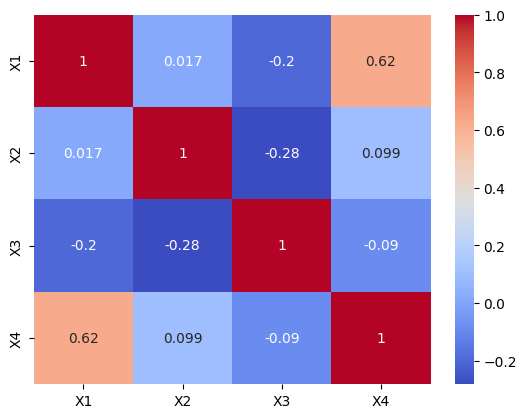

In [15]:
sns.heatmap(data.drop(columns=['country', 'Y']).corr(), annot=True, cmap='coolwarm')
plt.show()

In [16]:
print(data.head())

    country     Y     X1         X2  X3    X4
0  Bulgaria  75.8  14.66   7.933980  21  26.7
1   Czechia  79.9  29.33   8.421847  37  23.5
2   Denmark  81.8  62.91   9.594595  23  35.5
3   Germany  81.1  50.66  11.673909  14  28.7
4   Estonia  79.1  28.08   7.438437  24  36.0


In [17]:
y = data.Y

#### X - macierz zmiennych objaśniających, bez kolumny 'country' i 'Y', ale z logarytmem z 'X1'

In [36]:
X = data.drop(columns=['country', 'Y', 'X1'])
data['log_X1'] = np.log(data['X1'])
X = np.asarray(X.values)

y = np.asarray(y).reshape(-1, 1)

t = X.shape[0]
ones = np.ones(t)

X = np.column_stack([ones, X])
beta_head = np.linalg.inv(X.T.dot(X)).dot(X.T.dot(y))
print(beta_head)
print(f'\nB0 = {beta_head[0][0].round(4)}, B1 = {beta_head[1][0].round(4)}, B2 = {beta_head[2][0].round(4)}, B3 = {beta_head[3][0].round(4)}, B4 = {beta_head[4][0].round(4)}')


[[62.12193377]
 [ 0.6172219 ]
 [ 0.08320408]
 [ 0.0009251 ]
 [ 3.16898337]]

B0 = 62.1219, B1 = 0.6172, B2 = 0.0832, B3 = 0.0009, B4 = 3.169


### Wyznaczanie współczynnika zbieżności i determinacji:

#### zmienne do obliczeń: (warto znać)

In [46]:
T = data.shape[0] #Liczba obserwacji
k = X.shape[1] #liczba zmiennych ojaśniających
y_hat = X.dot(beta_head)
#s_2 = 1/(T-k) * (y - y_hat).T.dot(y - y_hat)
# alternatywnie
s_2 = 1/(T-k) * np.sum((y - y_hat)**2)
#lub jeszcze inaczej
#s_2 = 1/(T-k)*(y-X.dot(beta_head)).T.dot(y-X.dot(beta_head))
s = np.sqrt(s_2)

print(f'T = {T}, k = {k}')
print(f's² = {s_2.round(4)}, s = {s.round(4)}')

T = 27, k = 5
s² = 2.8795, s = 1.6969


In [65]:
# Współczynnik zmienności losowej
V = (s / abs(y.mean())) * 100
fi_2 = np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)
r2 = 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)
#lub
# r2 = 1 - fi_2

print(f'V = {V.round(4)}')
print(f'fi² = {fi_2.round(4)}')
print(f'R² = {r2.round(4)}')

V = 2.1019
fi² = 0.3464
R² = 0.6536


In [64]:
from sklearn.metrics import r2_score

# Obliczanie R^2
R2 = r2_score(y, X.dot(beta_head))
print(f"Współczynnik determinacji R^2: {R2}")

Współczynnik determinacji R^2: 0.6536416109458423


### Średnie błędy szacunku parametrów strukturalnych

In [ ]:
cov_matrix = s_2 * np.linalg.inv(X.T.dot(X))
print(f'macierz kowariancji:\n{cov_matrix.round(4)}')
print('--------------------------------------------')
var_beta = np.diag(cov_matrix) # wariancje estymatorów beta
se_beta = np.sqrt(var_beta) # odchylenia standardowe estymatorów beta \ średnie błędy szacunku
print(f'odchylenia standardowe estymatorów beta:\n{se_beta.round(4)}')


macierz kowariancji:
[[ 9.8586 -0.3144 -0.0906  0.0004 -1.3654]
 [-0.3144  0.0415  0.0022  0.0008 -0.0337]
 [-0.0906  0.0022  0.0022 -0.0001  0.0062]
 [ 0.0004  0.0008 -0.0001  0.003  -0.0288]
 [-1.3654 -0.0337  0.0062 -0.0288  0.6895]]
--------------------------------------------
odchylenia standardowe estymatorów beta:
[3.1398 0.2036 0.0468 0.0548 0.8304]
